In [65]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pmdarima.arima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math


In [66]:
df = pd.read_csv('D:\SohamInternshipWork\datasets\sample_acgl.txt')

In [67]:
print(df.shape)
print(df.info())

(3201, 7)
<class 'pandas.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3201 non-null   str    
 1   Open     3201 non-null   float64
 2   High     3201 non-null   float64
 3   Low      3201 non-null   float64
 4   Close    3201 non-null   float64
 5   Volume   3201 non-null   int64  
 6   OpenInt  3201 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 175.2 KB
None


In [68]:
df['Date']=pd.to_datetime(df['Date'])

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3201 non-null   datetime64[us]
 1   Open     3201 non-null   float64       
 2   High     3201 non-null   float64       
 3   Low      3201 non-null   float64       
 4   Close    3201 non-null   float64       
 5   Volume   3201 non-null   int64         
 6   OpenInt  3201 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 175.2 KB


In [70]:
df

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,13.583,13.693,13.430,13.693,156240,0
1,2005-02-28,13.697,13.827,13.540,13.827,370509,0
2,2005-03-01,13.780,13.913,13.720,13.760,224484,0
3,2005-03-02,13.717,13.823,13.667,13.810,286431,0
4,2005-03-03,13.783,13.783,13.587,13.630,193824,0
...,...,...,...,...,...,...,...
3196,2017-11-06,94.490,95.650,94.020,95.550,420192,0
3197,2017-11-07,95.860,95.950,95.200,95.560,464011,0
3198,2017-11-08,95.410,95.900,94.890,95.450,471756,0
3199,2017-11-09,94.930,96.140,94.470,95.910,353498,0


# Performing EDA

In [71]:
df.describe()

,Date,Open,High,Low,Close,Volume,OpenInt
count,3201,3201.000000,3201.000000,3201.000000,3201.000000,3.201000e+03,3201.0
mean,2011-07-05 17:50:12.933458,41.800246,42.127681,41.465992,41.826403,7.830475e+05,0.0
min,2005-02-25 00:00:00,13.170000,13.270000,11.010000,13.180000,5.236800e+04,0.0
25%,2008-05-01 00:00:00,22.653000,22.907000,22.370000,22.643000,3.591570e+05,0.0
50%,2011-07-06 00:00:00,33.100000,33.430000,32.800000,33.150000,5.823510e+05,0.0
75%,2014-09-10 00:00:00,57.550000,57.890000,57.240000,57.550000,1.033461e+06,0.0
max,2017-11-10 00:00:00,102.450000,102.600000,101.840000,102.380000,1.388090e+07,0.0
std,NaN,23.728163,23.847994,23.593876,23.730770,6.482674e+05,0.0


In [72]:
print(df.isna().sum())

Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64


No missing values found in the dataset

In [73]:
stock_data = df.set_index(df['Date'])

In [74]:
stock_data

,Date,Open,High,Low,Close,Volume,OpenInt
Date,,,,,,,
2005-02-25,2005-02-25,13.583,13.693,13.430,13.693,156240,0
2005-02-28,2005-02-28,13.697,13.827,13.540,13.827,370509,0
2005-03-01,2005-03-01,13.780,13.913,13.720,13.760,224484,0
2005-03-02,2005-03-02,13.717,13.823,13.667,13.810,286431,0
2005-03-03,2005-03-03,13.783,13.783,13.587,13.630,193824,0
...,...,...,...,...,...,...,...
2017-11-06,2017-11-06,94.490,95.650,94.020,95.550,420192,0
2017-11-07,2017-11-07,95.860,95.950,95.200,95.560,464011,0
2017-11-08,2017-11-08,95.410,95.900,94.890,95.450,471756,0


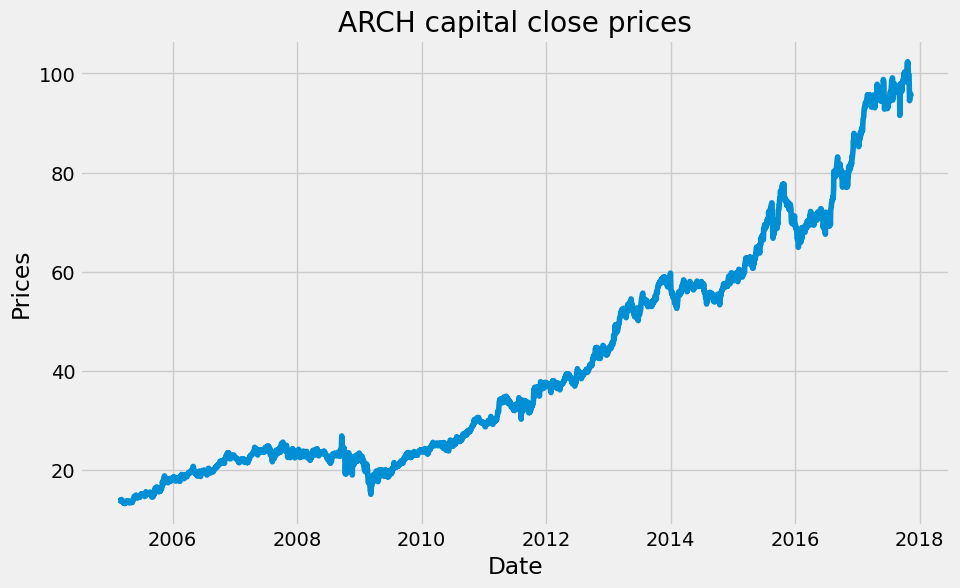

In [ ]:
    plt.figure(figsize=(10,6))
    plt.grid(True)
    plt.xlabel("Date")
    plt.ylabel('Prices')
    plt.plot(stock_data['Close'])
    plt.title("ARCH capital close prices")
    plt.show()

In [76]:
import seaborn as sns

In [77]:
print(pd.infer_freq(stock_data.index))

None


In [78]:
time_diffs = stock_data.index.to_series().diff()

In [79]:
print(time_diffs.value_counts().head(10))

Date
1 days    2509
3 days     578
4 days      83
2 days      28
5 days       2
Name: count, dtype: int64


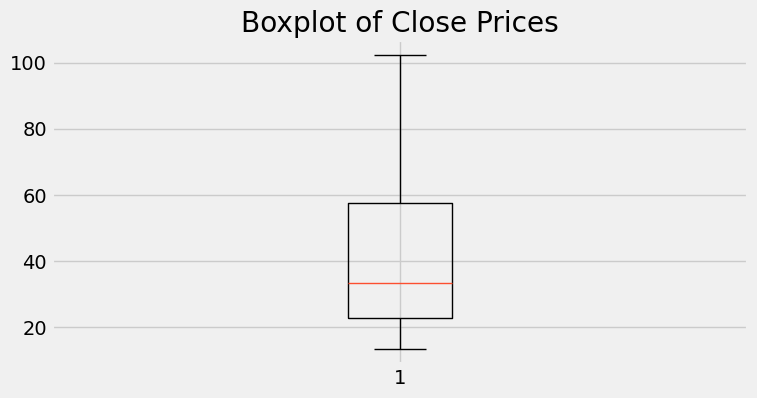

In [80]:
plt.figure(figsize=(8,4))

plt.boxplot(stock_data['Close'])

plt.title("Boxplot of Close Prices")

plt.show()

<Axes: ylabel='Density'>

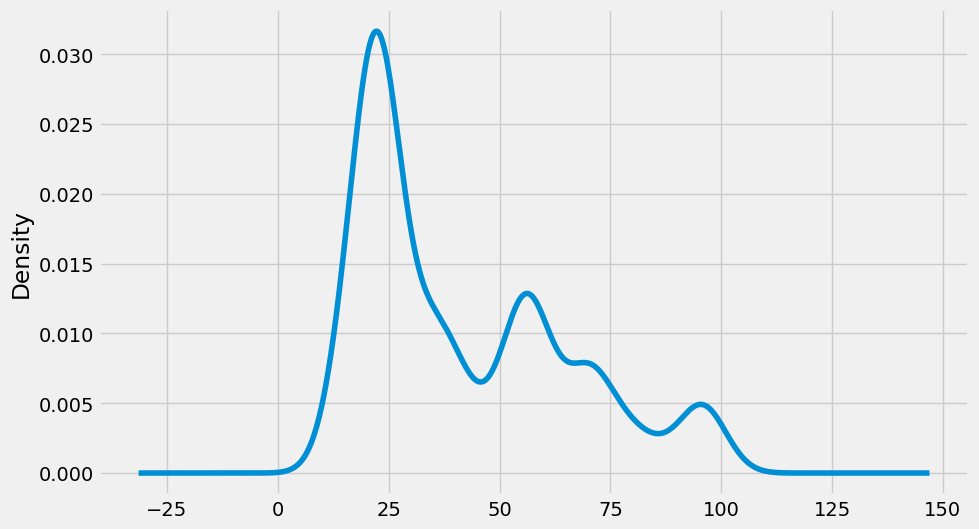

In [81]:
stock_data['Close'].plot(kind='kde')

Check seasonal decompositon 

<Figure size 1000x600 with 0 Axes>

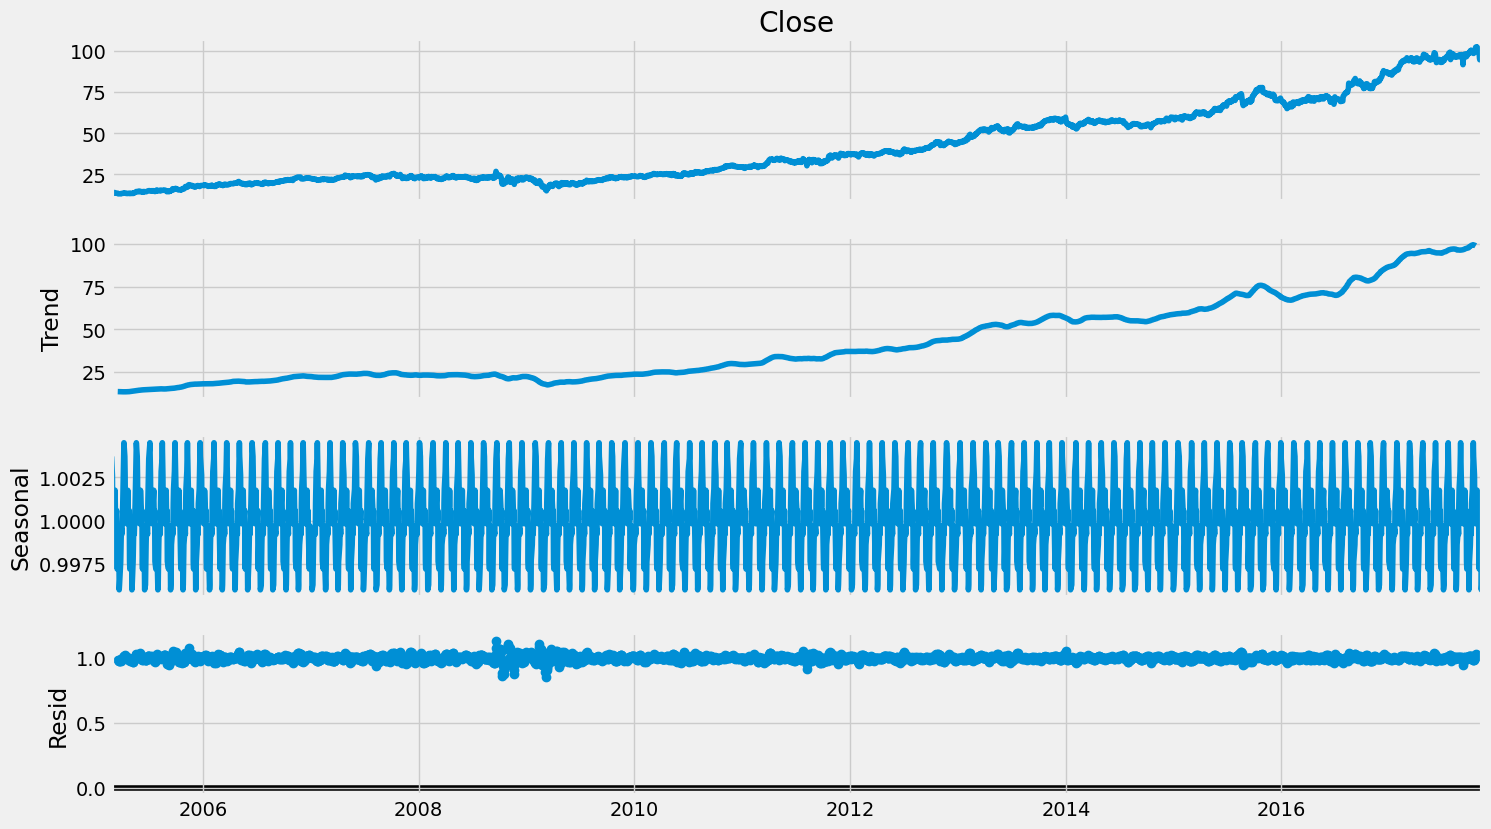

In [82]:
result = seasonal_decompose(stock_data['Close'],model='multiplicative',period=30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16,9)

    Now it becomes important to take log of the series to reduce the magnitude of values and reduce the rising trends 

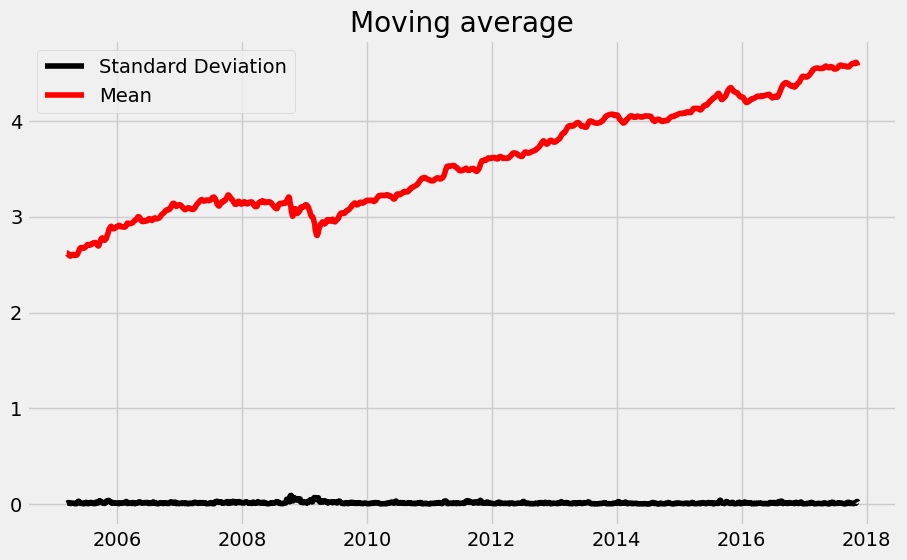

In [83]:
plt.figure(figsize=(10,6))
df_log = np.log(stock_data['Close'])
ma = df_log.rolling(12).mean()
std_dev = df_log.rolling(12).std()
plt.legend(loc='best')
plt.title('Moving average')
plt.plot(std_dev, color ="black", label = "Standard Deviation")
plt.plot(ma, color="red", label = "Mean")
plt.legend()
plt.show()

In [84]:
adf_test  = adfuller(stock_data['Close'])
print(f"p_value:{adf_test[1]}")

p_value:0.9969970726897868


Train-test split

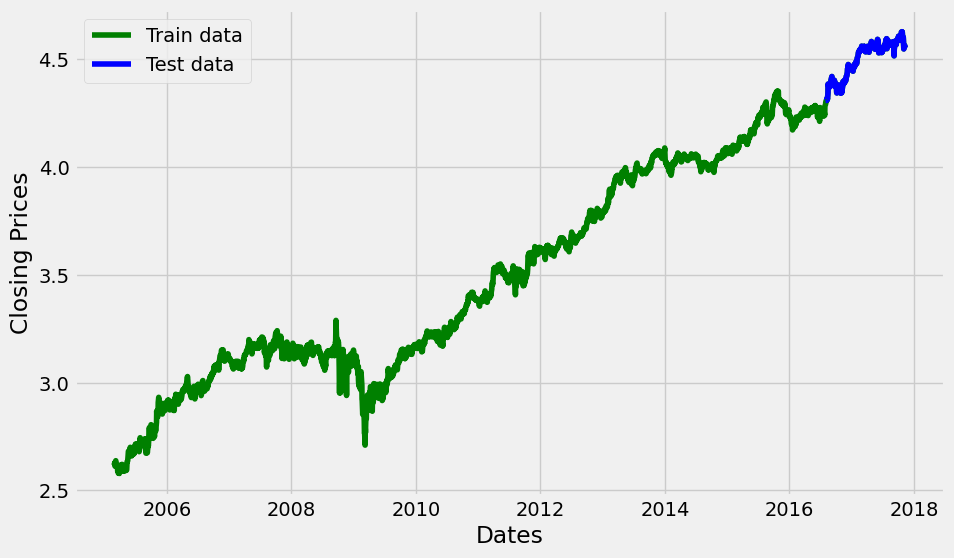

In [ ]:
train_data, test_data = df_log[3:int(len(df_log)*0.9)], df_log[int(len(df_log)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(df_log, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

<Axes: xlabel='Date'>

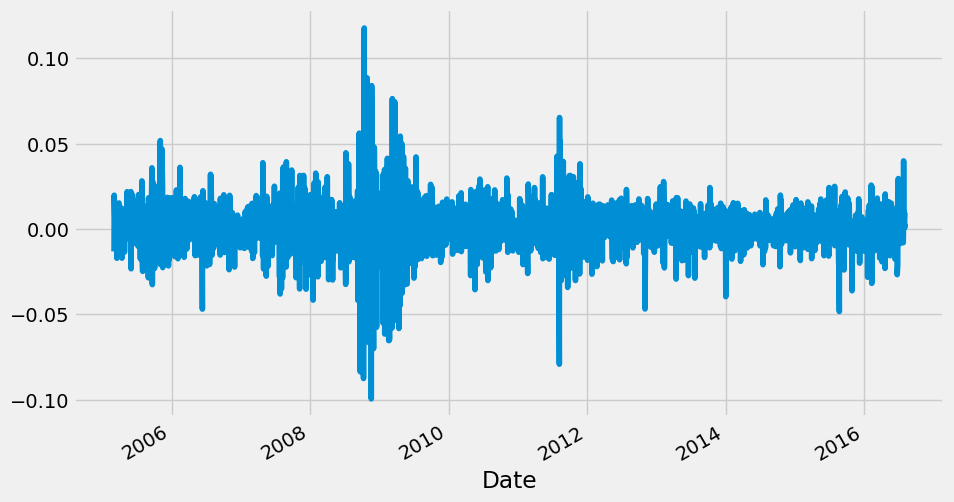

In [86]:
train_data_diff = train_data.diff().dropna()
train_data_diff.plot()

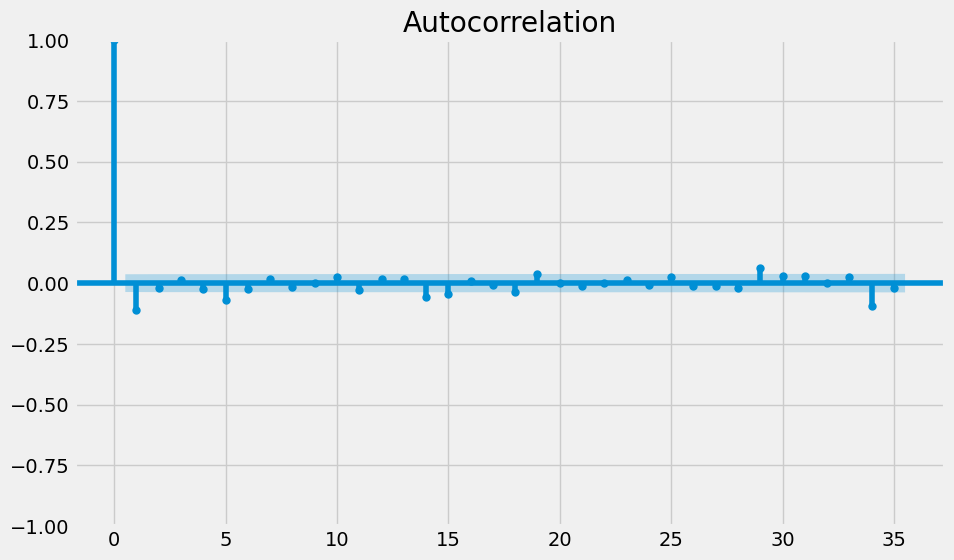

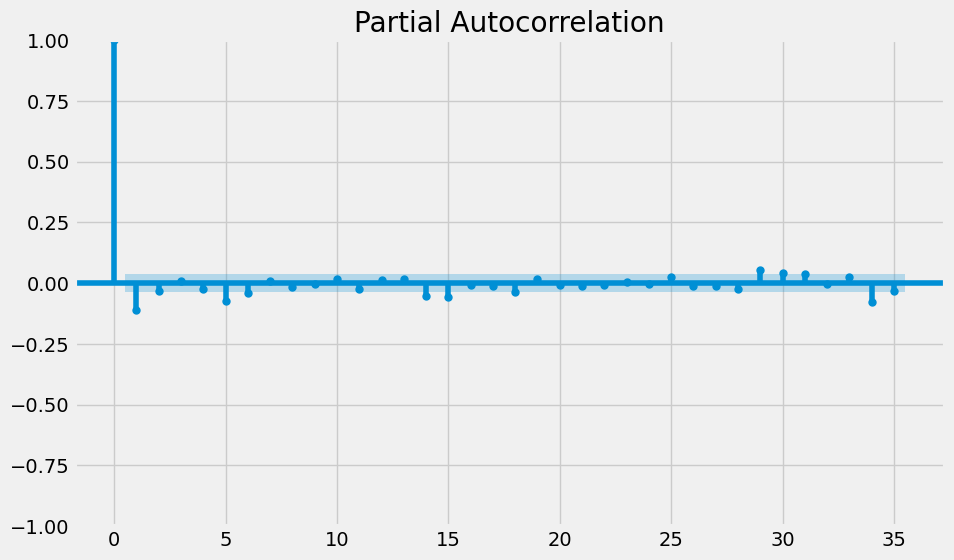

In [87]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
acf_diff = plot_acf(train_data_diff)
pacf_diff = plot_pacf(train_data_diff)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-16491.508, Time=0.85 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-16525.992, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-16527.964, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-16488.323, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-16527.157, Time=1.16 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-16527.120, Time=0.73 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-16528.810, Time=0.65 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-16526.020, Time=1.64 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-16524.974, Time=0.97 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-16525.435, Time=0.55 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-16516.417, Time=0.35 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-16527.597, Time=0.50 sec

Best model:  ARIMA(1,1,2)(0,0,0)[0] intercept
Total fit time: 10.231 seconds
  

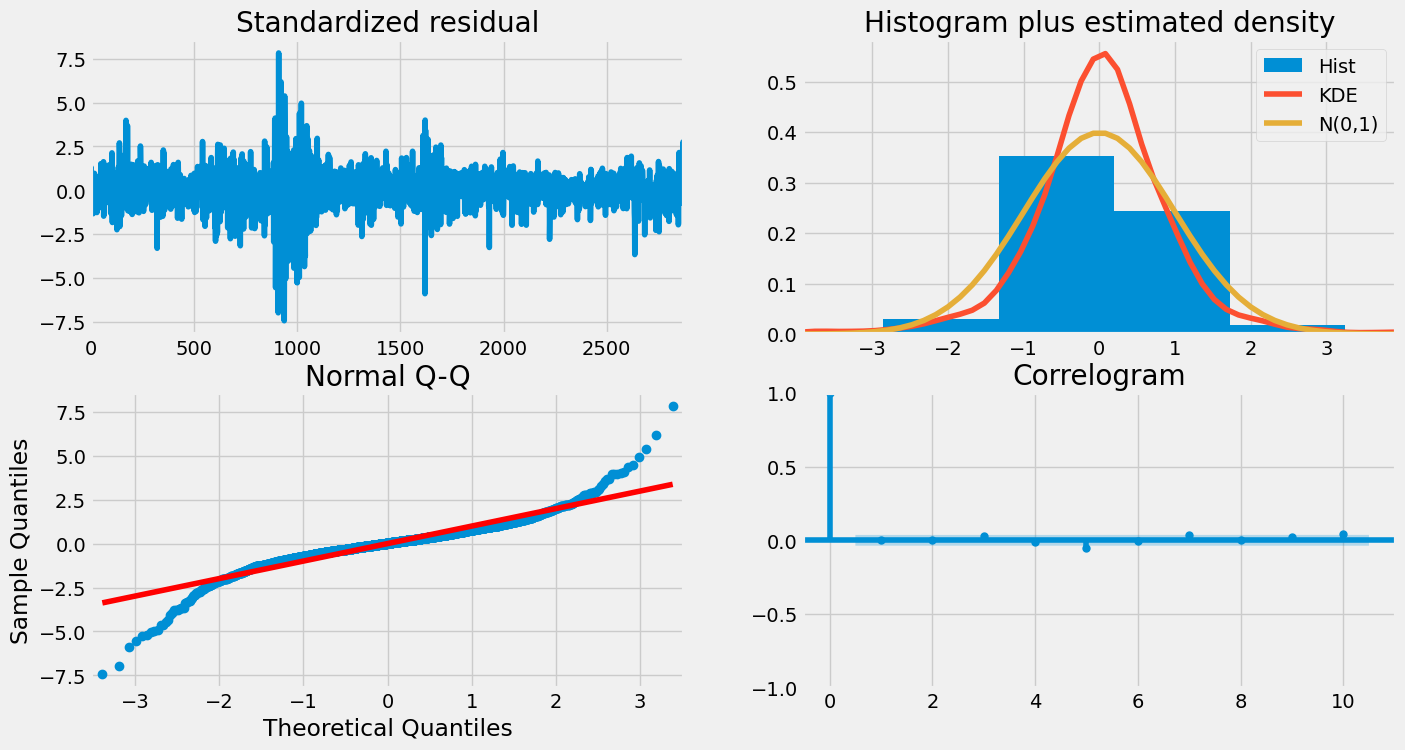

In [88]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [98]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data,order=(1,1,2))
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2877
Model:                 ARIMA(1, 1, 2)   Log Likelihood                8267.798
Date:                Mon, 25 May 2026   AIC                         -16527.597
Time:                        15:07:49   BIC                         -16503.740
Sample:                             0   HQIC                        -16518.997
                               - 2877                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8973      0.036     24.798      0.000       0.826       0.968
ma.L1         -1.0130      0.039    -25.731      0.000      -1.090      -0.936
ma.L2          0.0826      0.014      5.842      0.0

# Now again make the forecast series 

In [104]:
history = list(train_data)

predictions = []

for t in range(len(test_data)):

    model = ARIMA(history, order=(1,1,2))

    fitted = model.fit()

    forecast = fitted.forecast()

    yhat = forecast[0]

    predictions.append(yhat)

    actual = test_data.iloc[t]

    history.append(actual)

In [106]:
predictions_series = pd.Series(predictions, index=test_data.index)

In [117]:
trained_prices = np.exp(train_data)
actual_prices = np.exp(test_data)
predicted_prices = np.exp(predictions_series)

In [114]:
mse  = mean_squared_error(test_data, predictions)
mae  = mean_absolute_error(test_data, predictions)
rmse = math.sqrt(mse)
mape = np.mean(
    np.abs(
        (actual_prices - predicted_prices) / actual_prices
    )
) * 100



In [115]:
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MSE  : 0.000088
MAE  : 0.006683
RMSE : 0.009370
MAPE : 0.67%


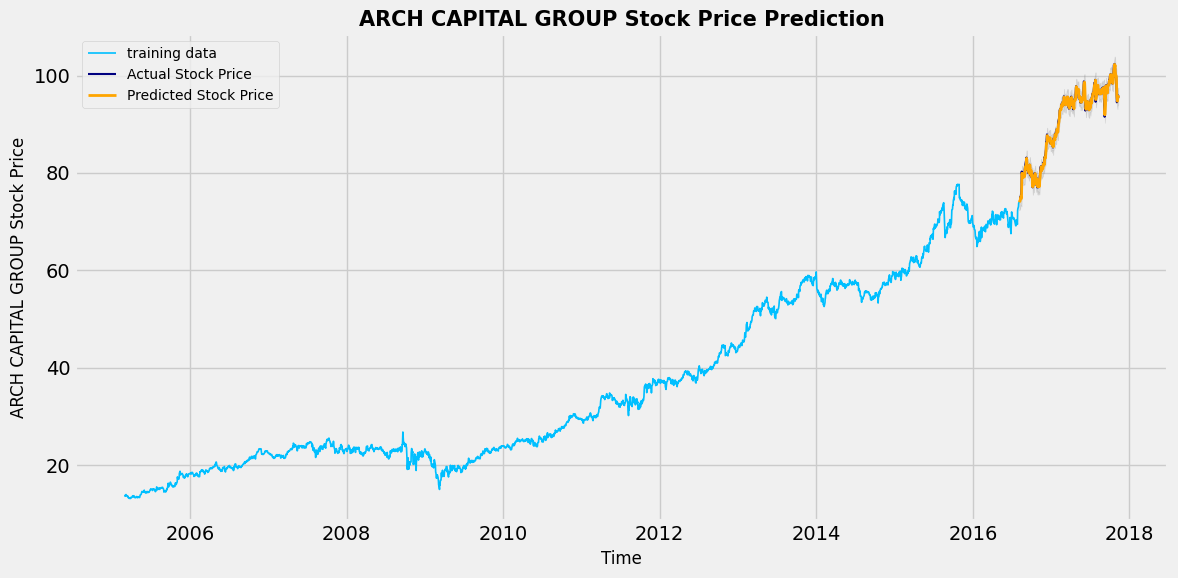

In [119]:
std_err = np.std(np.array(predicted_prices) - np.array(actual_prices))
 
fig, ax = plt.subplots(figsize=(12, 6))
 
# Training data — cyan
ax.plot(trained_prices, color='deepskyblue', linewidth=1.2, label='training data')
 
# Actual test prices — dark blue
ax.plot(actual_prices, color='navy', linewidth=1.5, label='Actual Stock Price')
 
# Predicted prices — orange
ax.plot(predicted_prices, color='orange', linewidth=2, label='Predicted Stock Price')
 
# 95% confidence interval shading
ax.fill_between(
    predicted_prices.index,
    predicted_prices - 1.96 * std_err,
    predicted_prices + 1.96 * std_err,
    color='gray', alpha=0.2
)
 
ax.set_title('ARCH CAPITAL GROUP Stock Price Prediction', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('ARCH CAPITAL GROUP Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# XGBoost

In [120]:
def create_lag_features(series, n_lags=10):
    df_feat = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat.dropna(inplace=True)
    X = df_feat.drop('y', axis=1).values
    y = df_feat['y'].values
    return X, y, df_feat.index
 
N_LAGS = 10

In [121]:
X_all, y_all, idx_all = create_lag_features(df_log, n_lags=N_LAGS)

In [122]:
split_idx = int(len(X_all) * 0.9)
X_train_xgb, X_test_xgb = X_all[:split_idx], X_all[split_idx:]
y_train_xgb, y_test_xgb = y_all[:split_idx], y_all[split_idx:]
idx_test_xgb = idx_all[split_idx:]

In [124]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    random_state=42,
    verbosity=0,
    eval_metric='rmse'  # <-- Moved here
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)]
)


[0]	validation_0-rmse:0.79994
[1]	validation_0-rmse:0.63702
[2]	validation_0-rmse:0.51148
[3]	validation_0-rmse:0.42801
[4]	validation_0-rmse:0.36321
[5]	validation_0-rmse:0.31547
[6]	validation_0-rmse:0.27866
[7]	validation_0-rmse:0.25267
[8]	validation_0-rmse:0.23213
[9]	validation_0-rmse:0.21751
[10]	validation_0-rmse:0.20684
[11]	validation_0-rmse:0.19885
[12]	validation_0-rmse:0.19371
[13]	validation_0-rmse:0.18991
[14]	validation_0-rmse:0.18637
[15]	validation_0-rmse:0.18499
[16]	validation_0-rmse:0.18400
[17]	validation_0-rmse:0.18338
[18]	validation_0-rmse:0.18298
[19]	validation_0-rmse:0.18219
[20]	validation_0-rmse:0.18212
[21]	validation_0-rmse:0.18166
[22]	validation_0-rmse:0.18155
[23]	validation_0-rmse:0.18150
[24]	validation_0-rmse:0.18133
[25]	validation_0-rmse:0.18131
[26]	validation_0-rmse:0.18130
[27]	validation_0-rmse:0.18181
[28]	validation_0-rmse:0.18181
[29]	validation_0-rmse:0.18180
[30]	validation_0-rmse:0.18179
[31]	validation_0-rmse:0.18177
[32]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [125]:
xgb_predictions = xgb_model.predict(X_test_xgb)
xgb_series = pd.Series(xgb_predictions, index=idx_test_xgb)
y_test_xgb_series = pd.Series(y_test_xgb, index=idx_test_xgb)

In [126]:
xgb_mse  = mean_squared_error(y_test_xgb, xgb_predictions)
xgb_mae  = mean_absolute_error(y_test_xgb, xgb_predictions)
xgb_rmse = math.sqrt(xgb_mse)
print("=== XGBoost ===")
print(f"MSE  : {xgb_mse:.6f}")
print(f"MAE  : {xgb_mae:.6f}")
print(f"RMSE : {xgb_rmse:.6f}")

=== XGBoost ===
MSE  : 0.033996
MAE  : 0.164176
RMSE : 0.184379


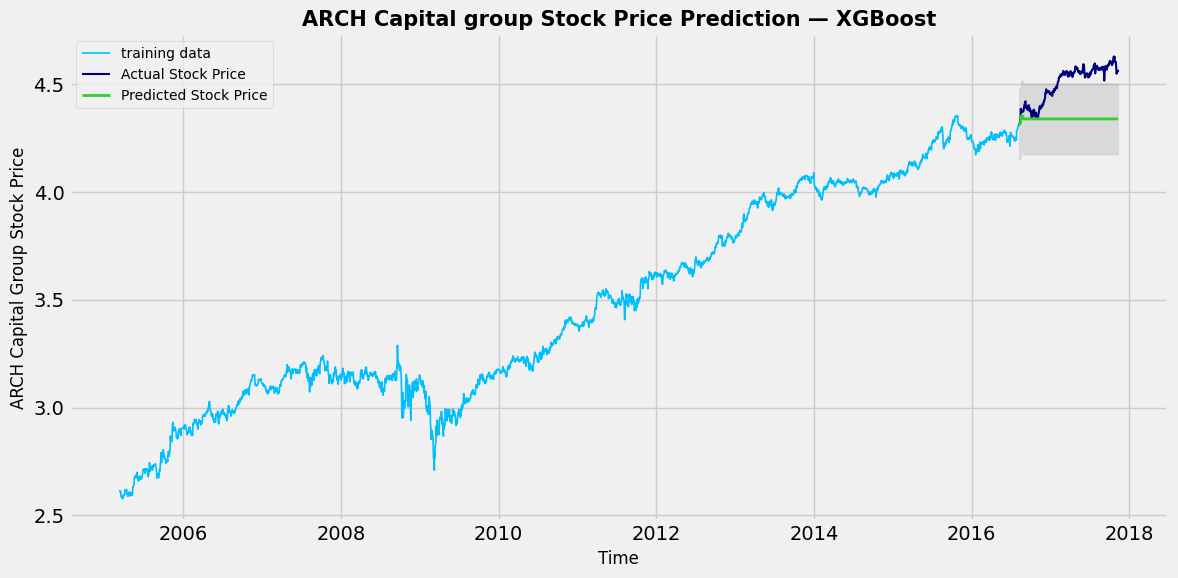

In [127]:
xgb_train_series = pd.Series(y_train_xgb, index=idx_all[:split_idx])
std_err_xgb = np.std(xgb_predictions - y_test_xgb)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xgb_train_series, color='deepskyblue', linewidth=1.2, label='training data')
ax.plot(y_test_xgb_series, color='navy', linewidth=1.5, label='Actual Stock Price')
ax.plot(xgb_series, color='limegreen', linewidth=2, label='Predicted Stock Price')
ax.fill_between(
    xgb_series.index,
    xgb_series - 1.96 * std_err_xgb,
    xgb_series + 1.96 * std_err_xgb,
    color='gray', alpha=0.2
)
ax.set_title('ARCH Capital group Stock Price Prediction — XGBoost', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('ARCH Capital Group Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# FB Prophet


In [128]:
from prophet import Prophet
prophet_df = pd.DataFrame({
    'ds': df_log.index,
    'y' : df_log.values
}).reset_index(drop=True)
 
# Use the same 90/10 split
split_n = int(len(prophet_df) * 0.9)
prophet_train = prophet_df.iloc[:split_n]
prophet_test  = prophet_df.iloc[split_n:]
 
# %%
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

10:25:05 - cmdstanpy - INFO - Chain [1] start processing
10:25:09 - cmdstanpy - INFO - Chain [1] done processing


In [129]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='B')  # 'B' = business days
prophet_forecast = prophet_model.predict(future)

In [130]:
prophet_pred = prophet_forecast.tail(len(prophet_test))[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
prophet_pred.set_index('ds', inplace=True)
prophet_pred.index = pd.to_datetime(prophet_pred.index)
 
prophet_actual_index = pd.to_datetime(prophet_test['ds'].values)
prophet_actual_series = pd.Series(prophet_test['y'].values, index=prophet_actual_index)
prophet_pred_series   = pd.Series(prophet_pred['yhat'].values, index=prophet_actual_index)
prophet_lower_series  = pd.Series(prophet_pred['yhat_lower'].values, index=prophet_actual_index)
prophet_upper_series  = pd.Series(prophet_pred['yhat_upper'].values, index=prophet_actual_index)

In [131]:
prophet_mse  = mean_squared_error(prophet_actual_series, prophet_pred_series)
prophet_mae  = mean_absolute_error(prophet_actual_series, prophet_pred_series)
prophet_rmse = math.sqrt(prophet_mse)
print("=== FB Prophet ===")
print(f"MSE  : {prophet_mse:.6f}")
print(f"MAE  : {prophet_mae:.6f}")
print(f"RMSE : {prophet_rmse:.6f}")

=== FB Prophet ===
MSE  : 0.012629
MAE  : 0.100463
RMSE : 0.112378


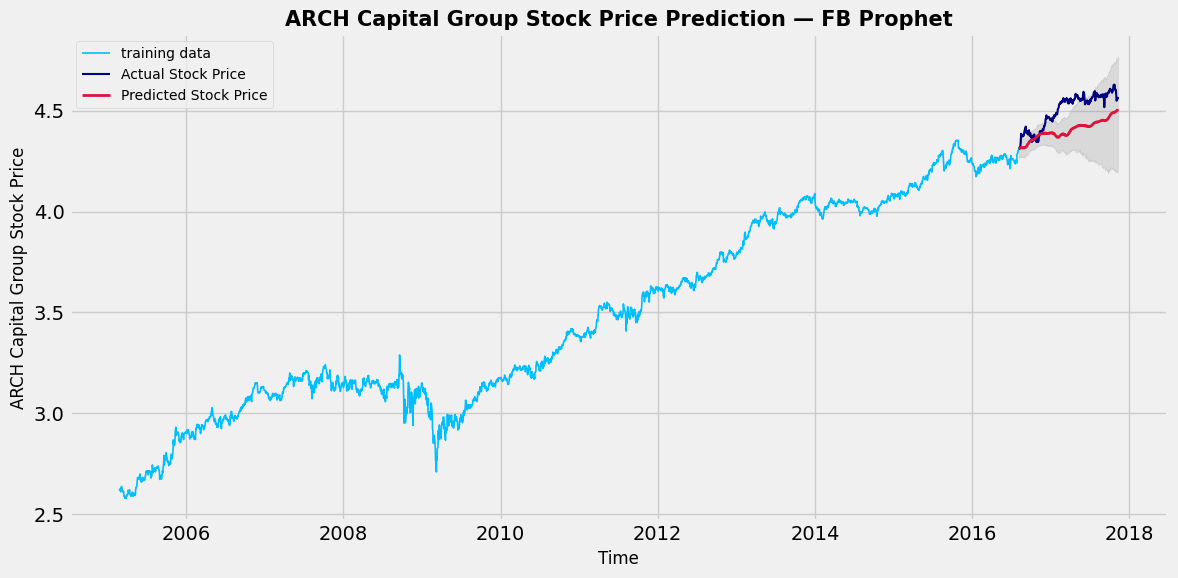

In [132]:
prophet_train_series = pd.Series(
    prophet_train['y'].values,
    index=pd.to_datetime(prophet_train['ds'].values)
)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(prophet_train_series, color='deepskyblue', linewidth=1.2, label='training data')
ax.plot(prophet_actual_series, color='navy', linewidth=1.5, label='Actual Stock Price')
ax.plot(prophet_pred_series, color='crimson', linewidth=2, label='Predicted Stock Price')
ax.fill_between(
    prophet_actual_index,
    prophet_lower_series,
    prophet_upper_series,
    color='gray', alpha=0.2
)
ax.set_title('ARCH Capital Group Stock Price Prediction — FB Prophet', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('ARCH Capital Group Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

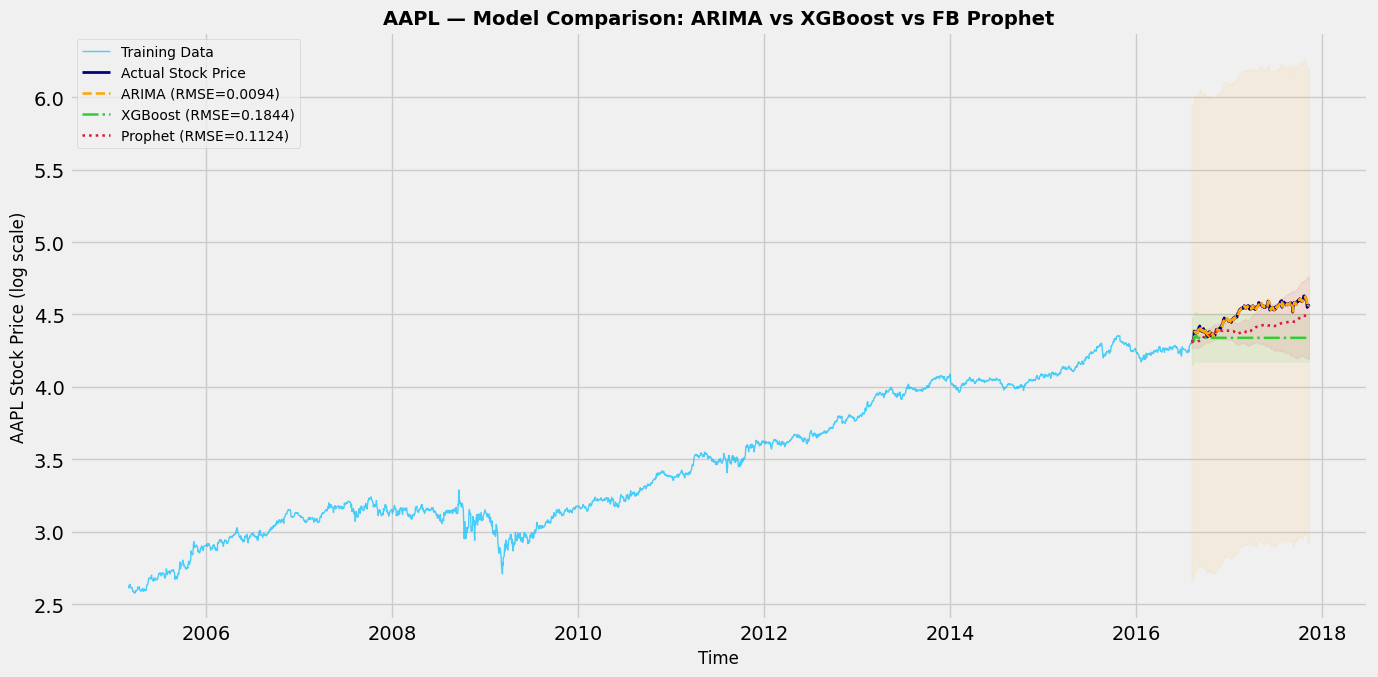

In [133]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_data, color='deepskyblue', linewidth=1.0, alpha=0.7, label='Training Data')
ax.plot(test_data, color='navy', linewidth=2.0, label='Actual Stock Price')
rmse_value = np.sqrt(mean_squared_error(test_data, predictions_series)) # Calculate your RMSE
ax.plot(predictions_series, color='orange', linewidth=1.8, linestyle='--', label=f'ARIMA (RMSE={rmse_value:.4f})')
ax.plot(xgb_series, color='limegreen', linewidth=1.8, linestyle='-.', label=f'XGBoost (RMSE={xgb_rmse:.4f})')
ax.plot(prophet_pred_series, color='crimson', linewidth=1.8, linestyle=':', label=f'Prophet (RMSE={prophet_rmse:.4f})')
ax.fill_between(
    predictions_series.index,
    predictions_series - 1.96 * std_err,
    predictions_series + 1.96 * std_err,
    color='orange', alpha=0.08
)
ax.fill_between(
    xgb_series.index,
    xgb_series - 1.96 * std_err_xgb,
    xgb_series + 1.96 * std_err_xgb,
    color='limegreen', alpha=0.08
)
ax.fill_between(
    prophet_actual_index,
    prophet_lower_series,
    prophet_upper_series,
    color='crimson', alpha=0.08
)
 
ax.set_title('AAPL — Model Comparison: ARIMA vs XGBoost vs FB Prophet',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('AAPL Stock Price (log scale)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


In [134]:
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'XGBoost', 'FB Prophet'],
    'MSE'  : [mse,    xgb_mse,    prophet_mse],
    'MAE'  : [mae,    xgb_mae,    prophet_mae],
    'RMSE' : [rmse,   xgb_rmse,   prophet_rmse],
})
metrics_df.set_index('Model', inplace=True)
print(metrics_df.to_string())

                 MSE       MAE      RMSE
Model                                   
ARIMA       0.000088  0.006683  0.009370
XGBoost     0.033996  0.164176  0.184379
FB Prophet  0.012629  0.100463  0.112378


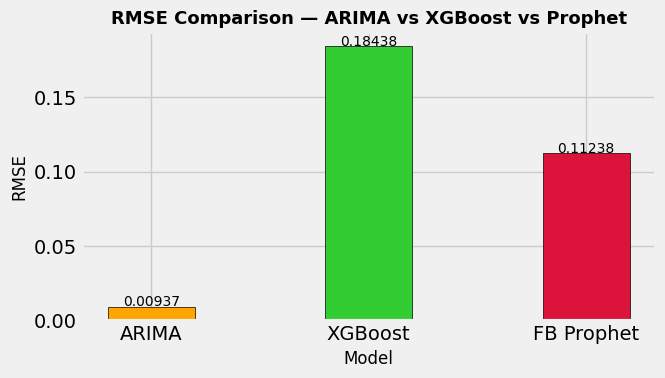

In [135]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['orange', 'limegreen', 'crimson']
ax.bar(metrics_df.index, metrics_df['RMSE'], color=colors, edgecolor='black', width=0.4)
ax.set_title('RMSE Comparison — ARIMA vs XGBoost vs Prophet', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
for i, (model, row) in enumerate(metrics_df.iterrows()):
    ax.text(i, row['RMSE'] + 0.0001, f"{row['RMSE']:.5f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()